In [1]:
# 02. Preprocessing Pipeline Demo
import sys
sys.path.append('../src')
from preprocessing import load_labeled_spectra, preprocess_spectrum
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')


/Users/akshaymohanrevankar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-9v9_7_b2 because there was an issue with the default path (/Users/akshaymohanrevankar/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Configuration
MZML_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Ecoli_EV_1.mzML"
XLSX_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Database search output_Ecoli_EV_1.xlsx"


In [3]:
# Load 5 sample spectra
spectra = load_labeled_spectra(MZML_PATH, XLSX_PATH, max_spectra=5)
print(f"Loaded {len(spectra)} spectra.")


Loaded 5 spectra.


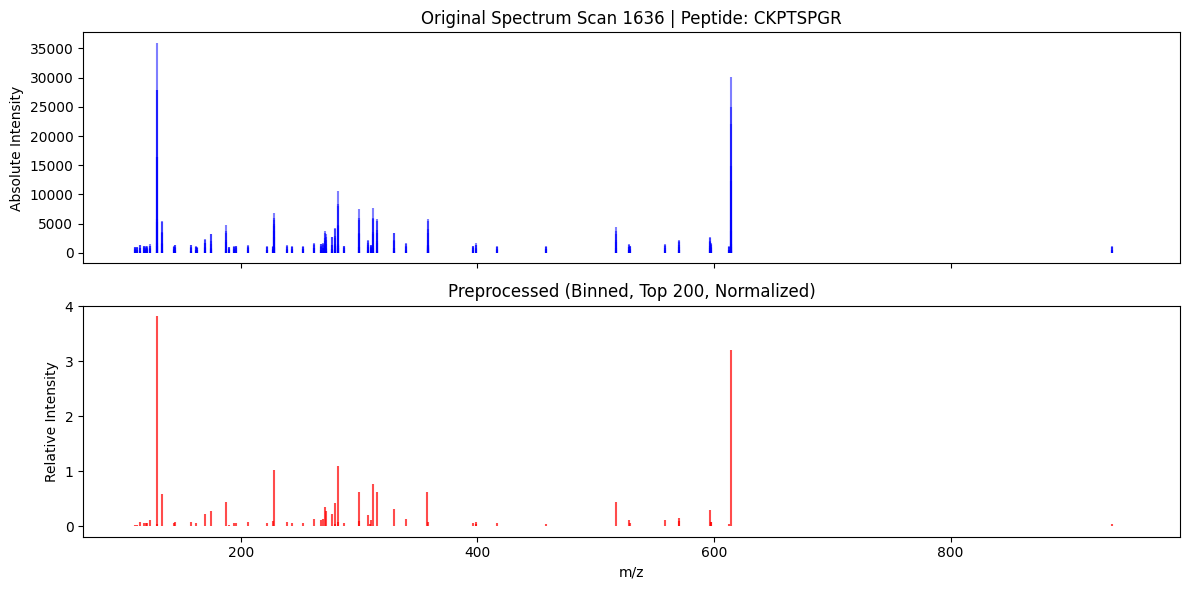

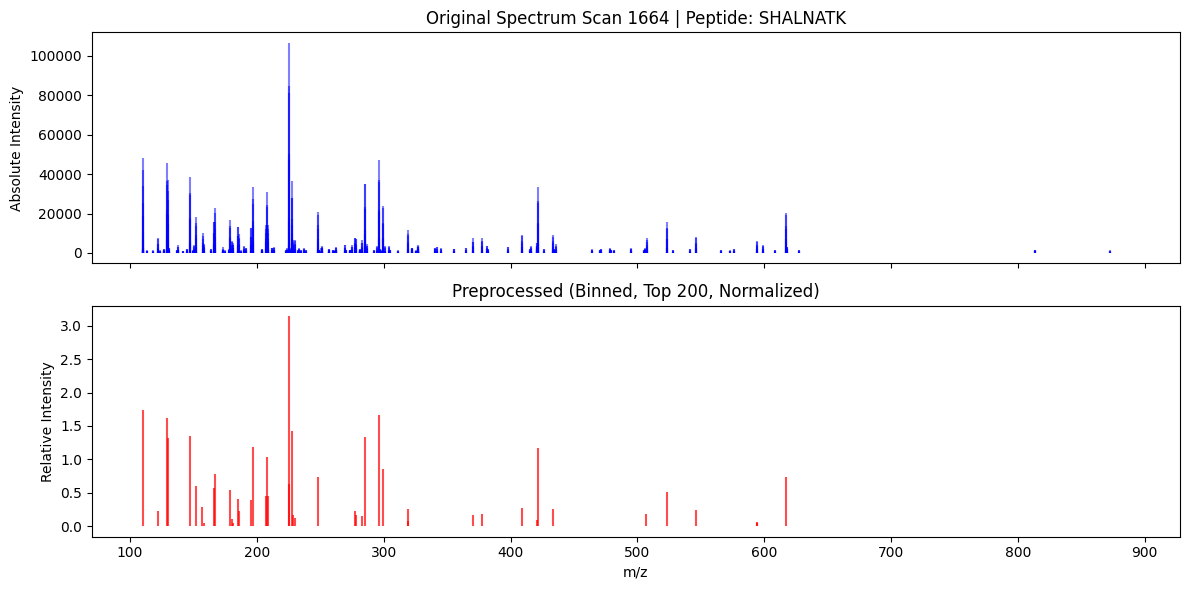

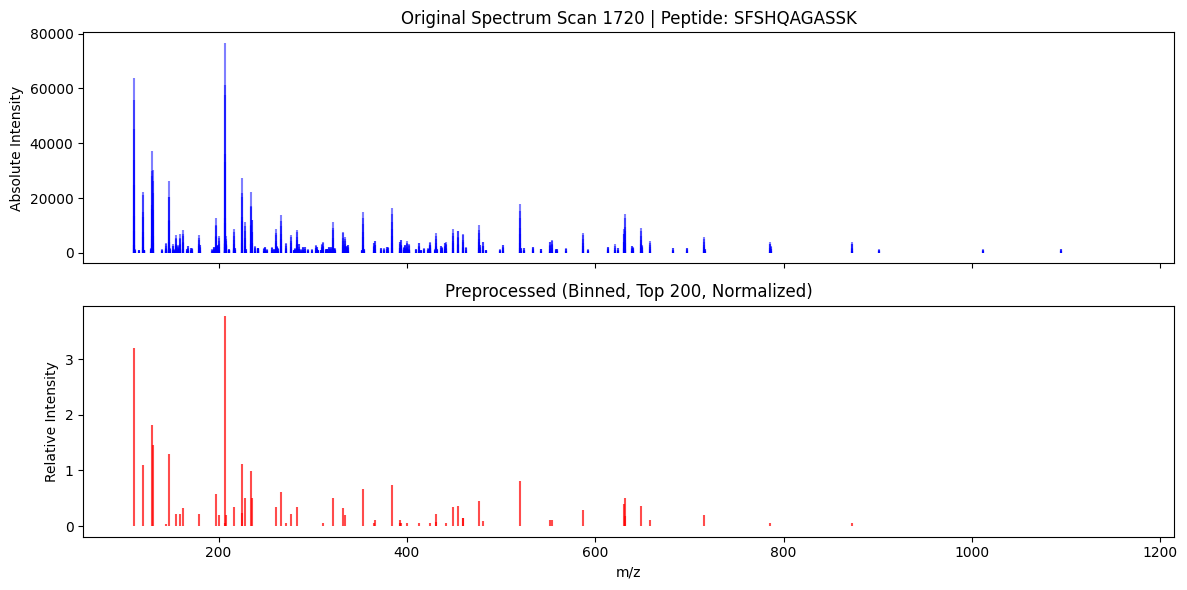

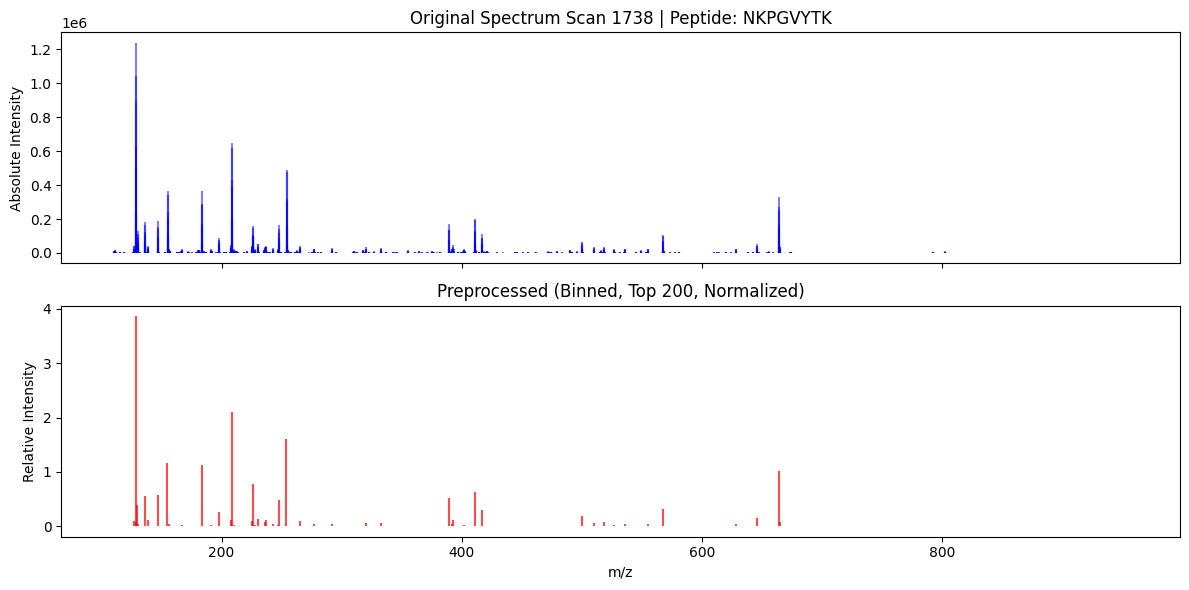

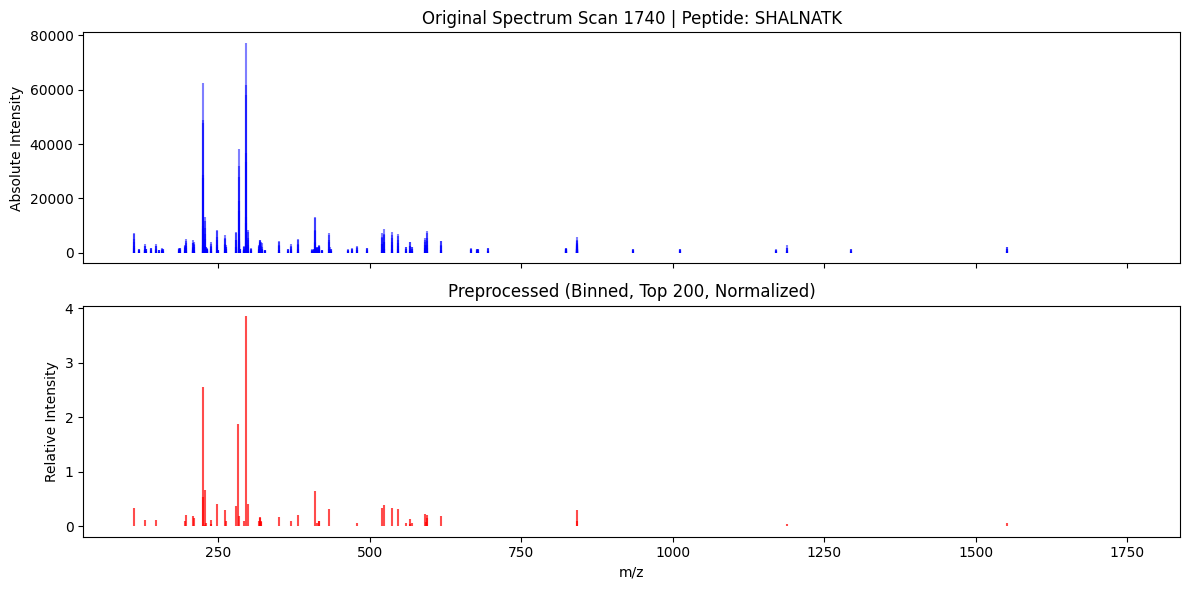

In [4]:
# Plot before / after for each spectrum
for i, s in enumerate(spectra):
    original_mz = s['mz']
    original_int = s['intensity']
    
    binned_vector = preprocess_spectrum(original_mz, original_int)
    
    # Reconstruct binned m/z array (bin size 0.1, max 2000)
    bin_mzs = np.linspace(0, 2000, len(binned_vector), endpoint=False)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # Original
    axes[0].vlines(original_mz, 0, original_int, color='blue', alpha=0.5)
    axes[0].set_title(f"Original Spectrum Scan {s['scan_num']} | Peptide: {s['peptide']}")
    axes[0].set_ylabel('Absolute Intensity')
    
    # Preprocessed
    mask = binned_vector > 0
    axes[1].vlines(bin_mzs[mask], 0, binned_vector[mask], color='red', alpha=0.7)
    axes[1].set_title(f"Preprocessed (Binned, Top 200, Normalized)")
    axes[1].set_xlabel('m/z')
    axes[1].set_ylabel('Relative Intensity')
    
    plt.tight_layout()
    plt.savefig(f'../figures/eda/preprocessed_demo_{s["scan_num"]}.png')
    plt.show()
